# Phase 2 — Multi-seed comparison & reward ablation

Goal of this notebook:

1. Train PPO and DQN at 5 seeds each (using the default `diff-waiting-time` reward)
2. Train PPO at 3 seeds for each of the 3 alternative reward functions
3. Evaluate every trained model on 5 held-out SUMO seeds
4. Aggregate results: PPO vs DQN table, reward ablation plot

**Note on runtime:** each training takes ~2–3h on Windows (TraCI), ~15min on Linux (libsumo).
Training cells are restartable — they skip models that already exist on disk.

---

## Setup

In [1]:
import ppo
import dqn
from evaluate import evaluate

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from stable_baselines3 import PPO, DQN

# Configuration
SEEDS = [42, 43, 44, 45, 46]            # training seeds for PPO vs DQN comparison
ABLATION_SEEDS = [42, 43, 44]            # training seeds for the reward ablation
REWARDS = ["pressure", "queue", "average-speed"]   # alternative rewards (default is diff-waiting-time)
EVAL_SEEDS = [100, 200, 300, 400, 500]   # held-out SUMO seeds for evaluation

## 1. Training

### 1a. Multi-seed: PPO and DQN with the default reward

In [2]:
for seed in SEEDS:
    ppo.train(seed=seed)
    dqn.train(seed=seed)

[ppo] seed42: already trained, skipping
[dqn] seed42: already trained, skipping
[ppo] seed43: already trained, skipping
[dqn] seed43: already trained, skipping
[ppo] seed44: already trained, skipping
[dqn] seed44: already trained, skipping
[ppo] seed45: already trained, skipping
[dqn] seed45: already trained, skipping
[ppo] seed46: already trained, skipping
[dqn] seed46: already trained, skipping


### 1b. Reward function ablation (PPO only)

In [3]:
for reward in REWARDS:
    for seed in ABLATION_SEEDS:
        ppo.train(seed=seed, reward_fn=reward)

[ppo] seed42_pressure: already trained, skipping
[ppo] seed43_pressure: already trained, skipping
[ppo] seed44_pressure: already trained, skipping
[ppo] seed42_queue: already trained, skipping
[ppo] seed43_queue: already trained, skipping
[ppo] seed44_queue: already trained, skipping
[ppo] seed42_average-speed: already trained, skipping
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
[ppo] training seed43_average-speed for 200,000 steps
Logging to tb\cologne1\ppo\seed43_average-speed\cologne1_2


c:\Users\kylian\anaconda3\envs\traffic-rl\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

-----------------------------------
| time/                |          |
|    fps               | 64       |
|    iterations        | 1        |
|    time_elapsed      | 15       |
|    total_timesteps   | 1024     |
| traffic/             |          |
|    mean_speed        | 2.22     |
|    mean_waiting_time | 10.7     |
|    total_stopped     | 27.2     |
-----------------------------------


c:\Users\kylian\anaconda3\envs\traffic-rl\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1.08e+03    |
|    ep_rew_mean          | 401         |
| time/                   |             |
|    fps                  | 67          |
|    iterations           | 2           |
|    time_elapsed         | 30          |
|    total_timesteps      | 2048        |
| traffic/                |             |
|    mean_speed           | 2.68        |
|    mean_waiting_time    | 10.5        |
|    total_stopped        | 23.1        |
| train/                  |             |
|    approx_kl            | 0.001923213 |
|    clip_fraction        | 0           |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.39       |
|    explained_variance   | -0.0054     |
|    learning_rate        | 0.0003      |
|    loss                 | 29.8        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00481    |
|    value_loss           | 61.7  

...

c:\Users\kylian\anaconda3\envs\traffic-rl\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 1.08e+03     |
|    ep_rew_mean          | 651          |
| time/                   |              |
|    fps                  | 114          |
|    iterations           | 195          |
|    time_elapsed         | 1737         |
|    total_timesteps      | 199680       |
| traffic/                |              |
|    mean_speed           | 5.94         |
|    mean_waiting_time    | 0.576        |
|    total_stopped        | 2.67         |
| train/                  |              |
|    approx_kl            | 0.0022976724 |
|    clip_fraction        | 0.0237       |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.261       |
|    explained_variance   | 0.952        |
|    learning_rate        | 0.0003       |
|    loss                 | 10.2         |
|    n_updates            | 1940         |
|    policy_gradient_loss | -0.000659    |
|    value_

c:\Users\kylian\anaconda3\envs\traffic-rl\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 1.08e+03     |
|    ep_rew_mean          | 651          |
| time/                   |              |
|    fps                  | 115          |
|    iterations           | 196          |
|    time_elapsed         | 1744         |
|    total_timesteps      | 200704       |
| traffic/                |              |
|    mean_speed           | 5.97         |
|    mean_waiting_time    | 0.872        |
|    total_stopped        | 2.58         |
| train/                  |              |
|    approx_kl            | 0.0014774335 |
|    clip_fraction        | 0.0189       |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.27        |
|    explained_variance   | 0.957        |
|    learning_rate        | 0.0003       |
|    loss                 | 9.65         |
|    n_updates            | 1950         |
|    policy_gradient_loss | -0.0011      |
|    value_

[ppo] saved -> checkpoints\cologne1\ppo\seed44_average-speed\final.zip


## 2. Evaluation

Load every trained model and evaluate it on 5 SUMO seeds. Combine everything into one tidy DataFrame.

In [4]:
def load_and_eval(algo, seed, reward_fn="diff-waiting-time"):
    """Load one model and run evaluate() on it. Returns DataFrame with metadata columns added."""
    tag = f"seed{seed}"
    if reward_fn != "diff-waiting-time":
        tag += f"_{reward_fn}"
    model_path = Path(f"checkpoints/cologne1/{algo}/{tag}/final.zip")
    if not model_path.exists():
        print(f"  missing: {model_path}")
        return None
    cls = PPO if algo == "ppo" else DQN
    print(f"Evaluating {algo} {tag}")
    model = cls.load(str(model_path))
    df = evaluate(model, eval_seeds=EVAL_SEEDS, reward_fn=reward_fn)
    df["algo"] = algo
    df["train_seed"] = seed
    df["reward_fn"] = reward_fn
    return df


frames = []

# Multi-seed runs
for seed in SEEDS:
    for algo in ["ppo", "dqn"]:
        df = load_and_eval(algo, seed)
        if df is not None:
            frames.append(df)

# Reward ablation runs (PPO only)
for reward in REWARDS:
    for seed in ABLATION_SEEDS:
        df = load_and_eval("ppo", seed, reward_fn=reward)
        if df is not None:
            frames.append(df)

results = pd.concat(frames, ignore_index=True)
print(f"\nTotal: {len(results)} eval rows across {results['train_seed'].nunique()} training seeds")
results.head()

Evaluating ppo seed42
  eval seed 100...
  eval seed 200...
  eval seed 300...
  eval seed 400...
  eval seed 500...
Evaluating dqn seed42
  eval seed 100...
  eval seed 200...
  eval seed 300...
  eval seed 400...
  eval seed 500...
Evaluating ppo seed43
  eval seed 100...
  eval seed 200...
  eval seed 300...
  eval seed 400...
  eval seed 500...
Evaluating dqn seed43
  eval seed 100...
  eval seed 200...
  eval seed 300...
  eval seed 400...
  eval seed 500...
Evaluating ppo seed44
  eval seed 100...
  eval seed 200...
  eval seed 300...
  eval seed 400...
  eval seed 500...
Evaluating dqn seed44
  eval seed 100...
  eval seed 200...
  eval seed 300...
  eval seed 400...
  eval seed 500...
Evaluating ppo seed45
  eval seed 100...
  eval seed 200...
  eval seed 300...
  eval seed 400...
  eval seed 500...
Evaluating dqn seed45
  eval seed 100...
  eval seed 200...
  eval seed 300...
  eval seed 400...
  eval seed 500...
Evaluating ppo seed46
  eval seed 100...
  eval seed 200...
  ev

,seed,mean_wait,mean_speed,mean_stopped,p95_wait,algo,train_seed,reward_fn
0,100,299.947702,5.706258,2.637963,1526.250000,ppo,42,diff-waiting-time
1,200,301.612945,5.706501,2.738889,1531.250000,ppo,42,diff-waiting-time
2,300,301.810681,5.787570,2.357407,1532.250000,ppo,42,diff-waiting-time
3,400,301.867887,5.819186,2.397222,1532.250000,ppo,42,diff-waiting-time
4,500,0.400421,5.840194,2.152778,2.001471,ppo,42,diff-waiting-time


## 3. Results

### 3a. Summary table — mean ± std across training seeds

In [5]:
summary = results.groupby(["algo", "reward_fn"]).agg(
    n_seeds=("train_seed", "nunique"),
    wait_mean=("mean_wait", "mean"),
    wait_std=("mean_wait", "std"),
    speed_mean=("mean_speed", "mean"),
    speed_std=("mean_speed", "std"),
    stopped_mean=("mean_stopped", "mean"),
    stopped_std=("mean_stopped", "std"),
    p95_mean=("p95_wait", "mean"),
    p95_std=("p95_wait", "std"),
).round(3)

summary

n_seeds  wait_mean  wait_std  speed_mean  speed_std  \
algo reward_fn                                                                
dqn  diff-waiting-time        5    134.440   463.878       5.253      1.198   
ppo  average-speed            3    181.175   152.669       5.667      0.056   
     diff-waiting-time        5     68.481   137.497       5.503      0.521   
     pressure                 3    100.900   147.059       5.550      0.132   
     queue                    3      0.441     0.066       5.522      0.136   

                        stopped_mean  stopped_std  p95_mean   p95_std  
algo reward_fn                                                         
dqn  diff-waiting-time        16.674       49.277   318.664  1096.756  
ppo  average-speed             2.799        0.320   919.724   774.905  
     diff-waiting-time         5.081        8.616   335.011   657.173  
     pressure                  2.714        0.300   511.555   746.196  
     queue                     2.583        0.206     1.986     0.494

### 3b. PPO vs DQN (on the default reward)

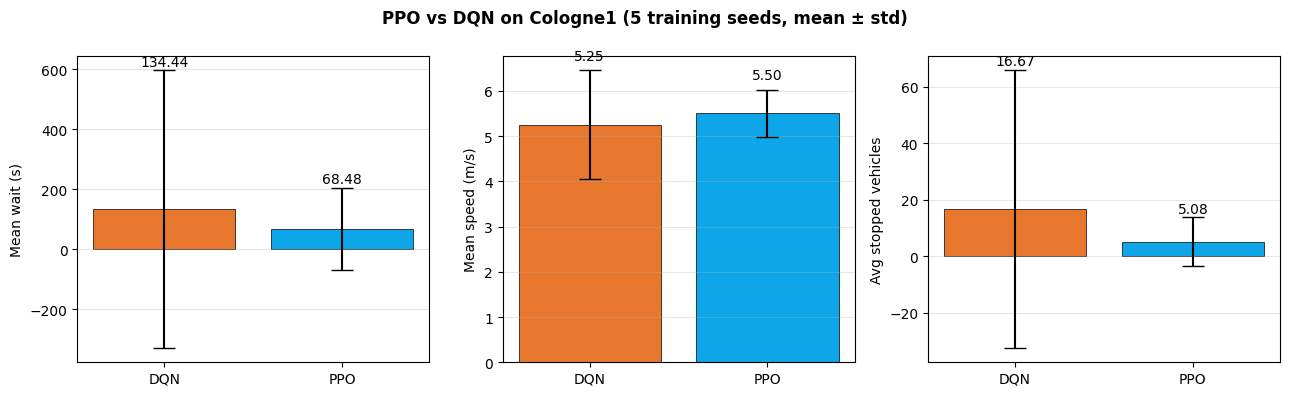

In [6]:
comp = results[results["reward_fn"] == "diff-waiting-time"]
agg = comp.groupby("algo").agg(
    wait_mean=("mean_wait", "mean"),
    wait_std=("mean_wait", "std"),
    speed_mean=("mean_speed", "mean"),
    speed_std=("mean_speed", "std"),
    stopped_mean=("mean_stopped", "mean"),
    stopped_std=("mean_stopped", "std"),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = {"ppo": "#0ea5e9", "dqn": "#e8772e"}

for ax, (col_mean, col_std, label) in zip(axes, [
    ("wait_mean", "wait_std", "Mean wait (s)"),
    ("speed_mean", "speed_std", "Mean speed (m/s)"),
    ("stopped_mean", "stopped_std", "Avg stopped vehicles"),
]):
    bar_colors = [colors[a] for a in agg["algo"]]
    ax.bar(agg["algo"].str.upper(), agg[col_mean], yerr=agg[col_std],
           color=bar_colors, capsize=8, edgecolor="black", linewidth=0.5)
    for i, (m, s) in enumerate(zip(agg[col_mean], agg[col_std])):
        ax.text(i, m + s + max(agg[col_mean]) * 0.03, f"{m:.2f}",
                ha="center", va="bottom", fontsize=10)
    ax.set_ylabel(label)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle(f"PPO vs DQN on Cologne1 ({len(SEEDS)} training seeds, mean ± std)", fontweight="bold")
fig.tight_layout()
plt.show()

### 3c. Reward function ablation (PPO)

C:\Users\kylian\AppData\Local\Temp\ipykernel_12744\3632872505.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(abl["reward_fn"], rotation=15, ha="right")
C:\Users\kylian\AppData\Local\Temp\ipykernel_12744\3632872505.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(abl["reward_fn"], rotation=15, ha="right")


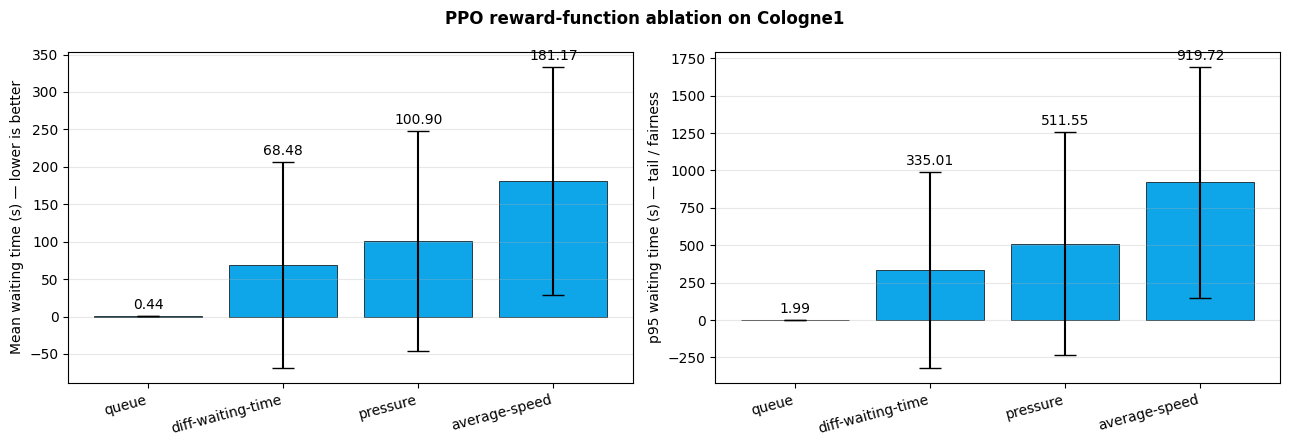

,reward_fn,wait_mean,wait_std,p95_mean,p95_std,n_seeds
3,queue,0.440891,0.065946,1.986169,0.494380,3
1,diff-waiting-time,68.480715,137.496778,335.011129,657.173446,5
2,pressure,100.900331,147.059255,511.554959,746.195710,3
0,average-speed,181.174847,152.669275,919.723515,774.905355,3


In [7]:
ppo_results = results[results["algo"] == "ppo"]
abl = ppo_results.groupby("reward_fn").agg(
    wait_mean=("mean_wait", "mean"),
    wait_std=("mean_wait", "std"),
    p95_mean=("p95_wait", "mean"),
    p95_std=("p95_wait", "std"),
    n_seeds=("train_seed", "nunique"),
).reset_index().sort_values("wait_mean")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (col_mean, col_std, label) in zip(axes, [
    ("wait_mean", "wait_std", "Mean waiting time (s) — lower is better"),
    ("p95_mean",  "p95_std",  "p95 waiting time (s) — tail / fairness"),
]):
    ax.bar(abl["reward_fn"], abl[col_mean], yerr=abl[col_std],
           color="#0ea5e9", capsize=8, edgecolor="black", linewidth=0.5)
    for i, (m, s) in enumerate(zip(abl[col_mean], abl[col_std])):
        ax.text(i, m + s + max(abl[col_mean]) * 0.03, f"{m:.2f}",
                ha="center", va="bottom", fontsize=10)
    ax.set_ylabel(label)
    ax.set_xticklabels(abl["reward_fn"], rotation=15, ha="right")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("PPO reward-function ablation on Cologne1", fontweight="bold")
fig.tight_layout()
plt.show()

abl

### 3d. Save the summary table for the next report

In [8]:
out_path = Path("outputs/cologne1/phase2_summary.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)
summary.to_csv(out_path)
print(f"Saved -> {out_path}")

Saved -> outputs\cologne1\phase2_summary.csv
